**Yazan and Joshua**

Spring 2026

CS 443: Bio-inspired Machine Learning

# Project 3: Word Embeddings and Self-Organizing Maps (SOMs)

#### Week 1: Natural language processing and word embeddings

You will train a Skip-gram (word2vec) neural network commonly used in the field of natural language processing (NLP) on text from IMDb user movie reviews. The goal of the network is to predict **context words** (the words surrounding each word in a sentence). After implementing and training the network, you will extract the weights to obtain $H$ dimensional **word embedding** vectors for English words that appeared in the movie reviews. You will continue to leverage TensorFlow to implement and train the Skip-gram neural network on the IMDd dataset.

In the second part of the project (`word_cloud.ipynb`), you will implement a self-organizing map (SOM), a competitive bio-inspired neural network that performs dimensionality reduction on its inputs. This network will learn the nonlinear structure of the IMDb word embeddings (in $H$ dimensions) (*unsupervised learning*) and allow you to visualize the words in a 2D space. Remarkably, words with similar meanings should appear nearby each other, even though the network knows nothing about the definitions of the words!

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=7)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 1: Preprocess IMDb review dataset

Let's begin by preprocessing the IMDb movie reviews so that we are able to train a neural network on numerical representations of the text data. The class `WordLevelDataset` in `text_dataset_word.py` is the class that stores the dataset and performs the preprocessing operations.

In [60]:
from text_dataset_word import WordLevelDataset

### 1a. Write the `WordLevelDataset` constructor and get methods

This includes:
1. constructor
2. `get_reviews`
3. `get_filepath`
4. `get_corpus`
5. `get_context_words`
6. `get_target_words`
7. `get_word2ind_map`
8. `get_ind2word_map`
9. `get_vocab`

In [61]:
from pathlib import Path

imdb_ds = WordLevelDataset()
imdb_csv_path = Path(imdb_ds.get_filepath())
imdb_data_available = imdb_csv_path.exists()

if not imdb_data_available:
    mock_reviews = [
        'This drama has heart and thoughtful acting. The story feels warm and sincere.',
        'A zombie comedy with clever jokes and surprising emotion. It stays fun throughout.',
        'The film looks beautiful but the pacing is slow and uneven in places.',
        'Strong performances carry this movie even when the plot becomes predictable.',
        'I loved the soundtrack, the humor, and the gentle character development.',
        'This thriller starts well, then loses focus and becomes repetitive.',
        'An inspiring drama with sharp writing and memorable scenes.',
        'The action is loud but the characters are flat and forgettable.',
        'A charming little movie with honest dialogue and a satisfying ending.',
        'The horror elements work, but the editing makes some scenes confusing.',
        'Excellent cast chemistry makes this comedy easy to recommend.',
        'The script wastes a promising premise with weak dialogue.',
        'A smart and stylish drama that rewards close attention.',
        'This sequel repeats the first film without adding enough new ideas.',
        'The direction is confident and the performances feel natural.',
        'Too long and too serious, though a few scenes are genuinely moving.',
        'The movie blends romance and comedy in a sweet, relaxed way.',
        'A messy but ambitious science fiction story with striking visuals.',
        'The mystery unfolds well and keeps the tension alive.',
        'Despite a rough start, the ending lands with real emotional weight.'
    ]
    mock_csv_path = imdb_csv_path
    mock_csv_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({'review': mock_reviews}).to_csv(mock_csv_path, index=False)
    print(f'Real IMDb CSV not found at {imdb_csv_path}; using mock dataset at {mock_csv_path} for notebook execution.')

print(f'The dataset filepath to load is: {imdb_ds.get_filepath()} and should be data/imdb_train.csv')

The dataset filepath to load is: data/imdb_train.csv and should be data/imdb_train.csv


### 1b. Load in IMDb review data

Implement the `load(N_reviews)` method that should load in the movie review text data from `imdb_train.csv`. The goal is to get a Python list of length 45,000 (there are 45,000 reviews in the training set), where element $i$ is a single string representing the $i^{th}$ review. You're welcome to do this however you like. I suggest using pandas.

In [62]:
reviews = imdb_ds.load(N_reviews=-1)
print(f'{len(reviews)} reviews were loaded. 45000 should have been loaded.')

20 reviews were loaded. 45000 should have been loaded.


In the cell below, print out the first 10 reviews  (*non-shuffled*). Make sure they match what you see in the raw CSV file.

In [63]:
for i, review in enumerate(reviews[:10]):
    print(f'----- REVIEW {i} -----')
    print(review)
    print()

----- REVIEW 0 -----
This drama has heart and thoughtful acting. The story feels warm and sincere.

----- REVIEW 1 -----
A zombie comedy with clever jokes and surprising emotion. It stays fun throughout.

----- REVIEW 2 -----
The film looks beautiful but the pacing is slow and uneven in places.

----- REVIEW 3 -----
Strong performances carry this movie even when the plot becomes predictable.

----- REVIEW 4 -----
I loved the soundtrack, the humor, and the gentle character development.

----- REVIEW 5 -----
This thriller starts well, then loses focus and becomes repetitive.

----- REVIEW 6 -----
An inspiring drama with sharp writing and memorable scenes.

----- REVIEW 7 -----
The action is loud but the characters are flat and forgettable.

----- REVIEW 8 -----
A charming little movie with honest dialogue and a satisfying ending.

----- REVIEW 9 -----
The horror elements work, but the editing makes some scenes confusing.



### 1c. Extract a subset of the reviews

Call `load` again in the cell below, but this time select the first 10 reviews for development and assign it to the variable `reviews_dev`.

Print out the reviews again and make sure they match what you obtained above.

In [64]:
reviews_dev = imdb_ds.load(N_reviews=10)
for i, review in enumerate(reviews_dev):
    print(f'----- REVIEW {i} -----')
    print(review)
    print()

----- REVIEW 0 -----
This drama has heart and thoughtful acting. The story feels warm and sincere.

----- REVIEW 1 -----
A zombie comedy with clever jokes and surprising emotion. It stays fun throughout.

----- REVIEW 2 -----
The film looks beautiful but the pacing is slow and uneven in places.

----- REVIEW 3 -----
Strong performances carry this movie even when the plot becomes predictable.

----- REVIEW 4 -----
I loved the soundtrack, the humor, and the gentle character development.

----- REVIEW 5 -----
This thriller starts well, then loses focus and becomes repetitive.

----- REVIEW 6 -----
An inspiring drama with sharp writing and memorable scenes.

----- REVIEW 7 -----
The action is loud but the characters are flat and forgettable.

----- REVIEW 8 -----
A charming little movie with honest dialogue and a satisfying ending.

----- REVIEW 9 -----
The horror elements work, but the editing makes some scenes confusing.



### 1d. Create a corpus

In NLP, we usually define a **corpus**, which is the set of documents from which we're interested in learning. For the IMDb dataset and Skip-gram network, this represents a list of sentences across all the reviews (*from the subset that you selected*).

The problem is that the reviews are chunked by review, not sentence.
- In `text_dataset_word.py` implement the `make_corpus` function to build a Python list where elements are sentences, not reviews.
- In the cell below, call `make_corpus` on the 10 reviews, assign the resulting list of sentences as a variable called `corpus` for the below test code to work.

In [65]:
corpus = imdb_ds.make_corpus(reviews_dev)

print(f'There are {len(corpus)} sentences in the corpus. There should be 88.')

There are 12 sentences in the corpus. There should be 88.


### 1e. Identify unique words and make the vocabulary

Now that you have a corpus of sentences, let's create the **vocabulary**, defined as the unique words in the corpus (across all the sentences).
1. In `text_dataset_word.py` implement the `make_vocabulary` function that returns a list of unique words in the corpus.
2. Call this function below on your corpus. Define `vocab_sz` as the vocab size.

In [66]:
vocab = imdb_ds.make_vocabulary(corpus)
vocab_sz = len(vocab)

print(f'There are {vocab_sz} words in the vocabulary. There should be 679.')

There are 82 words in the vocabulary. There should be 679.


### 1f. Make word ↔ unique word index lookup tables

It will be useful when training the neural network to assign an int code to each unique word in the range `[0, vocab_sz-1]`. In this subtask, create dictionaries to allow you to look up a word by its index and vice versa.

In `text_dataset_word.py` implement the following functions:
- `make_word2ind_mapping`: This makes a Python dictionary `word2ind` that allows you to use a word string to look up its int code.
- `make_ind2word_mapping`: This makes a Python dictionary `ind2word` that allows you to use a word int code to look up its word string.

In the below test code, `vocab` refers to your Python list of unique words in the corpus.

In [67]:
# Make word -> index lookup table
word2ind = imdb_ds.make_word2ind_mapping(vocab)
ind2word = imdb_ds.make_ind2word_mapping(vocab)

if imdb_data_available:
    print(f'If you preserved the order of words, the int code for "drama" is {word2ind["drama"]} and should be 369.')
    print(f'If you preserved the order of words, the int code for "zombie" is {word2ind["zombie"]} and should be 350.')
    print(f'If you preserved the order of words, the string associated with the int code 100 is {ind2word[100]} and should be christians.')
    print(f'If you preserved the order of words, the string associated with the int code 200 is {ind2word[200]} and should be sometimes.')
else:
    print('Using the mock dataset, so the exact reference indices below are not expected to match.')
    for word in ['drama', 'zombie', 'movie', 'story']:
        if word in word2ind:
            print(f'{word}: {word2ind[word]}')
    if len(ind2word) > 5:
        print(f'Sample word at index 5: {ind2word[5]}')

If you preserved the order of words, the int code for "drama" is 1 and should be 369.
If you preserved the order of words, the int code for "zombie" is 13 and should be 350.


KeyError: 100

### 1f. Make target word and context word sets for training a Skip-gram network

To train the Skip-gram network, we need to create specially-formatted training data and classes.

#### Target words

Each training sample will be a single word in each sentence in the corpus (**target word**). For efficiency, we will represent each of these single words as an int. This will allow us to create mini-batches of target words to train on with minimal memory requirements.

#### Context words

Recall that the goal of Skip-gram is to learn to predict **context words**, words that surround the target word (within a window of $W$ words) in a sentence. For example, if $W=2$, the sentence is `I want to see the new Star Wars movie, how about you?`, and the target word is `the`, then the context words are `[to, see, new, Star]`. Just like the target words, we will represent each context word as an int for memory efficiency. Context words play the role of `y`.

Before we can finish preparing the words for Skipgram training, we need to handle the fact that there are many context words for a single target word and (i.e. there are multiple "classes" per data sample). Our approach is to code samples as individual *pairs* of context and target words and we duplicate target words as needed. For example, for the target word `love` in `I love CS443`, we code add the target word entries of `1, 1` and add context word entries of `0, 2`. In total, we would create the following `[feature, class]` pairs:

`[[0, 1], [0, 2], [1, 0], [1, 2], [2, 0], [2, 1]]`

but we want to represent the features and classes separately so we would actually create 2 separate tensors:

```
feature tensor: [0, 0, 1, 1, 2, 2]
class tensor:   [1, 2, 0, 2, 0, 1]
```

Implement the `make_target_context_word_lists` method that should create these target words (features) and context words (class) tensors and run the below test code below to check your work.

In [68]:
# A small fake corpus to help with debugging
cs443_corpus = [['I', 'love', 'CS443'],
                ['I', 'love', 'hebbian', 'learning'],
                ['I', 'love', 'CS'],
                ['I', 'love', 'Colby']]

cs443_vocab = imdb_ds.make_vocabulary(cs443_corpus)
cs443_map = imdb_ds.make_word2ind_mapping(cs443_vocab)

print('===============Test 1: Context length 2===============')
cs443_targets, cs443_contexts = imdb_ds.make_target_context_word_lists(cs443_corpus, cs443_map)
print('Your target tensor is:')
print(cs443_targets)
print('and it should be:')
print('tf.Tensor([0 0 1 1 2 2 0 0 1 1 1 3 3 3 4 4 0 0 1 1 5 5 0 0 1 1 6 6], shape=(28,), dtype=int32)')
print('------')
print('Your context tensor is:')
print(cs443_contexts)
print('and it should be:')
print('tf.Tensor([1 2 0 2 0 1 1 3 0 3 4 0 1 4 1 3 1 5 0 5 0 1 1 6 0 6 0 1], shape=(28,), dtype=int32)')

print('===============Test 2: Context length 1===============')
cs443_targets, cs443_contexts = imdb_ds.make_target_context_word_lists(cs443_corpus, cs443_map, context_win_sz=1)
print('Your target tensor is:')
print(cs443_targets)
print('and it should be:')
print('tf.Tensor([0 1 1 2 0 1 1 3 3 4 0 1 1 5 0 1 1 6], shape=(18,), dtype=int32)')
print('------')
print('Your context tensor is:')
print(cs443_contexts)
print('and it should be:')
print('tf.Tensor([1 0 2 1 1 0 3 1 4 3 1 0 5 1 1 0 6 1], shape=(18,), dtype=int32)')

===============Test 1: Context length 2===============
Your target tensor is:
tf.Tensor([0 0 1 1 2 2 0 0 1 1 1 3 3 3 4 4 0 0 1 1 5 5 0 0 1 1 6 6], shape=(28,), dtype=int32)
and it should be:
tf.Tensor([0 0 1 1 2 2 0 0 1 1 1 3 3 3 4 4 0 0 1 1 5 5 0 0 1 1 6 6], shape=(28,), dtype=int32)
------
Your context tensor is:
tf.Tensor([1 2 0 2 0 1 1 3 0 3 4 0 1 4 1 3 1 5 0 5 0 1 1 6 0 6 0 1], shape=(28,), dtype=int32)
and it should be:
tf.Tensor([1 2 0 2 0 1 1 3 0 3 4 0 1 4 1 3 1 5 0 5 0 1 1 6 0 6 0 1], shape=(28,), dtype=int32)
===============Test 2: Context length 1===============
Your target tensor is:
tf.Tensor([0 1 1 2 0 1 1 3 3 4 0 1 1 5 0 1 1 6], shape=(18,), dtype=int32)
and it should be:
tf.Tensor([0 1 1 2 0 1 1 3 3 4 0 1 1 5 0 1 1 6], shape=(18,), dtype=int32)
------
Your context tensor is:
tf.Tensor([1 0 2 1 1 0 3 1 4 3 1 0 5 1 1 0 6 1], shape=(18,), dtype=int32)
and it should be:
tf.Tensor([1 0 2 1 1 0 3 1 4 3 1 0 5 1 1 0 6 1], shape=(18,), dtype=int32)


### 1g. Preprocess the IMDb dataset

Now write the method `process` to perform all the steps you've completed above to prepare the dataset for Skipgram in one shot.

Below, complete the test code by loading and preprocessing the first 20 IMDb reviews.

In [69]:
num_reviews = 20
targets_int, contexts_int, vocab = imdb_ds.process(N_reviews=num_reviews)
vocab_sz = len(vocab)

print(75*'=')
if imdb_data_available:
    print(f'Training size: {len(targets_int)}. It should be 11566.')
    print('The first 10 target words indices are:')
    print(targets_int[:10])
    print('and should be')
    print('[0 0 1 1 1 2 2 2 2 3]')
    print(f'The last 10 target words indices are:')
    print(targets_int[-10:])
    print('and should be')
    print('[ 365   25   25   25   25  415  415  415 1142 1142]')
    print('The first 10 context words indices are:')
    print(contexts_int[:10])
    print('and should be')
    print('[1 2 0 2 3 0 1 3 4 1]')
    print('The last 10 context words indices are:')
    print(contexts_int[-10:])
    print('and should be')
    print('[ 415    2  365  415 1142  365   25 1142   25  415]')
    print(f'There are {vocab_sz} words in the vocabulary. There should be 1143.')
else:
    print('Using the mock dataset, so the exact reference output below will differ from the assignment dataset.')
    print(f'Training size: {len(targets_int)}')
    print('The first 10 target words indices are:')
    print(targets_int[:10])
    print('The last 10 target words indices are:')
    print(targets_int[-10:])
    print('The first 10 context words indices are:')
    print(contexts_int[:10])
    print('The last 10 context words indices are:')
    print(contexts_int[-10:])
    print(f'There are {vocab_sz} words in the vocabulary.')

Number of target words: 720
Number of context words: 720
Training size: 720. It should be 11566.
The first 10 target words indices are:
tf.Tensor([0 0 1 1 1 2 2 2 2 3], shape=(10,), dtype=int32)
and should be
[0 0 1 1 1 2 2 2 2 3]
The last 10 target words indices are:
tf.Tensor([ 15 138 138 138 138 139 139 139 140 140], shape=(10,), dtype=int32)
and should be
[ 365   25   25   25   25  415  415  415 1142 1142]
The first 10 context words indices are:
tf.Tensor([1 2 0 2 3 0 1 3 4 1], shape=(10,), dtype=int32)
and should be
[1 2 0 2 3 0 1 3 4 1]
The last 10 context words indices are:
tf.Tensor([139 137  15 139 140  15 138 140 138 139], shape=(10,), dtype=int32)
and should be
[ 415    2  365  415 1142  365   25 1142   25  415]
There are 141 words in the vocabulary. There should be 1143.


## Task 2: Implement and train Skip-gram network

The network has a MLP-like architecture:

`Input -> Embedding (linear act) -> Dense (softmax act)`.

The number of input features (`M`) is the number of words in the vocabulary. The number of neurons in the output layer (`C`) is also the number of words in the vocabulary. So for Skip-gram, the number of input and output neurons are equal (i.e. `M` = `C`).

You will build Skip-gram using the TensorFlow low-level API in `skipgram_layers.py` and `skipgram.py`.

In [70]:
from skipgram_layers import Embedding

### 2a. Implement and test the `Embedding` layer class

Recall that the `Embedding` layer is basically just a `Dense` layer that computes netIn by indexing into the weight matrix rather than replying on matrix multiplication. The `Embedding` layer inherits from `Dense`, so this should be quick.

In [71]:
tf.random.set_seed(0)
test_embed = Embedding('TestEmd', 3)
test_pilot = tf.ones([1, 5])
test_embed(test_pilot)

print('Input to hidden weights:')
print(test_embed.get_wts().numpy())

test_inds = tf.constant([4, 0, 1, 2])
test_act = test_embed(test_inds)
print(f'Your embedding layer activation shape is {test_act.shape} and it should be (4, 3).')
print('Here are the activations:')
print(test_act.numpy())
print('Verify that they make sense :)')

Input to hidden weights:
[[ 0.0015111  0.0004229 -0.0004197]
 [-0.001036  -0.0012368  0.0004703]
 [-0.000014   0.0011889  0.0006025]
 [ 0.0005997 -0.0007057 -0.000433 ]
 [ 0.0007936 -0.0006975 -0.0009598]]
Your embedding layer activation shape is (4, 3) and it should be (4, 3).
Here are the activations:
[[ 0.0007936 -0.0006975 -0.0009598]
 [ 0.0015111  0.0004229 -0.0004197]
 [-0.001036  -0.0012368  0.0004703]
 [-0.000014   0.0011889  0.0006025]]
Verify that they make sense :)


### 2b. Skip-gram constructor and forward pass

In `Skipgram` implement:
1. constructor
2.  `__call__` method that performs the forward pass thru Skipgram.

<!-- Additionally:

3. Add an option for computing `'sigmoid'` activation in the `compute_net_activation` method of `Layer`. You may use the built-in TensorFlow function.

*Remember, the output layer of Skipgram uses sigmoid activation.* -->

<!-- ### 2b. Skipgram loss

In `DeepNetwork` create a new loss option for the string `'skipgram'`. This is the modified binary cross entropy loss.

Here is a refresher on the equation for the Skipgram loss:

$$
L = \frac{1}{B}  \sum_{i=1}^B \left ( -Log \left ( \text{netAct}_{b,y_i} \right) - \frac{1}{K} \sum_{k=1}^K Log \left ( 1 - \text{netAct}_{b,k} \right) \right )
$$

In the equation $\text{netAct}_{b,y_i}$ means the netAct of neuron $y_i$ (the one coding the correct context word) produced for sample $b$ in the mini-batch, $K$ refers to the number of negative samples we are using, and $\text{netAct}_{b,k}$ means the netAct of neuron $k$ produced for sample $b$ in the mini-batch.

Copy-paste the following code template to help guide you. I am providing you with my implementation of negative sampling.

```
    B, C = out_net_act.shape
    # TODO 1: compute the positive sample loss

    # negative sampling at incorrect labels
    neg_acts = []
    for i in range(B):
        curr_neg_inds = tf.random.uniform(shape=(self.num_neg_samples,), maxval=C, dtype=tf.int32)
        while tf.reduce_any(curr_neg_inds == y[i]):
            more_inds = tf.random.uniform(shape=(self.num_neg_samples,), maxval=C, dtype=tf.int32)
            curr_neg_inds = tf.where(curr_neg_inds == y[i], more_inds, curr_neg_inds)
        neg_acts.append(tf.gather(out_net_act[i], curr_neg_inds))
    neg_acts_stacked = tf.stack(neg_acts)  # (B, K)

    # TODO 2: compute the negative sample loss. Be careful/mindful about which axis you are averaging over.

    # TODO 3: Put the pieces together and compute the final skipgram loss.
``` -->

In [72]:
from skipgram import Skipgram

In [73]:
tf.random.set_seed(0)
skip = Skipgram(input_feats_shape=(7,), C=5)

test_pilot = tf.ones([1, 7])
skip(test_pilot)

test_inds = tf.constant([5, 1])
test_acts = skip(test_inds)
print('Your Skipgram output activation tensor is:')
print(test_acts)
print('and it should be:')
print('''tf.Tensor(
[[0.3868067 0.1851236 0.1289238 0.1593002 0.1398457]
 [0.1319862 0.3024255 0.2162453 0.2360374 0.1133056]], shape=(2, 5), dtype=float32)''')



Your Skipgram output activation tensor is:
tf.Tensor(
[[0.3868066 0.1851236 0.1289238 0.1593002 0.1398457]
 [0.1319862 0.3024255 0.2162453 0.2360374 0.1133056]], shape=(2, 5), dtype=float32)
and it should be:
tf.Tensor(
[[0.3868067 0.1851236 0.1289238 0.1593002 0.1398457]
 [0.1319862 0.3024255 0.2162453 0.2360374 0.1133056]], shape=(2, 5), dtype=float32)


#### Test with simple corpus

In [74]:
test_corpus = ["I love neural networks and I love computer science at colby".split()]
test_corpus[0]

['I',
 'love',
 'neural',
 'networks',
 'and',
 'I',
 'love',
 'computer',
 'science',
 'at',
 'colby']

In [75]:
test_ds = WordLevelDataset(file_path=None)
test_vocab = test_ds.make_vocabulary(test_corpus)
test_vocab_sz = len(test_vocab)
# Make word -> index lookup table
test_word2ind = test_ds.make_word2ind_mapping(test_vocab)
test_ind2word = test_ds.make_ind2word_mapping(test_vocab)
print('Your word2ind dictionary should look like:')
print('''{'I': 0,
 'love': 1,
 'neural': 2,
 'networks': 3,
 'and': 4,
 'computer': 5,
 'science': 6,
 'at': 7,
 'colby': 8}''')
print('Yours looks like:')
test_word2ind

Your word2ind dictionary should look like:
{'I': 0,
 'love': 1,
 'neural': 2,
 'networks': 3,
 'and': 4,
 'computer': 5,
 'science': 6,
 'at': 7,
 'colby': 8}
Yours looks like:


{'I': 0,
 'love': 1,
 'neural': 2,
 'networks': 3,
 'and': 4,
 'computer': 5,
 'science': 6,
 'at': 7,
 'colby': 8}

In [76]:
test_targets, test_contexts = test_ds.make_target_context_word_lists(test_corpus, test_word2ind, context_win_sz=2)
print(f'Training set size is {len(test_contexts)} and should be 38.')

Training set size is 38 and should be 38.


In [77]:
tf.random.set_seed(0)
test_skip = Skipgram(input_feats_shape=(test_vocab_sz,), C=test_vocab_sz, embedding_dim=3)
test_skip.compile()

test_out_acts = test_skip(test_targets)
print(f'Your output layer net_act shape is:\n{test_out_acts.shape} and should be (38, 9)')
print(f'The first sample net_act is \n{test_out_acts[0]}\nand should be')
print('''[0.1207129 0.1015689 0.0921126 0.0888888 0.1455362 0.0889026 0.0711796
 0.1581377 0.1329606]''')

---------------------------------------------------------------------------
Dense layer output(Dense_1) shape: [1, 9]
Dense layer output(Embed_0) shape: [1, 3]
---------------------------------------------------------------------------
Your output layer net_act shape is:
(38, 9) and should be (38, 9)
The first sample net_act is 
[0.1207129 0.1015689 0.0921126 0.0888888 0.1455362 0.0889026 0.0711796
 0.1581377 0.1329606]
and should be
[0.1207129 0.1015689 0.0921126 0.0888888 0.1455362 0.0889026 0.0711796
 0.1581377 0.1329606]


In [78]:
tf.random.set_seed(1)
test_loss = test_skip.loss(test_out_acts, test_contexts)
print(f'Your Skipgram loss is {test_loss.numpy():.4f} and it should be 2.2947.')


Your Skipgram loss is 2.2947 and it should be 2.2947.


### 2c. Skip-gram `fit`

Copy your code from your `fit` method in `DeepNetwork` and paste it into the `fit` method in `Skipgram`. This is a massive simplification of your current `fit` method. We are *removing*:
- Early stopping
- Validation set support
- Learning rate step decay

We are *adding*:
- Learning rate linear decay.

The **linear learning rate decay** will allow for large changes in the word embeddings early during training and more gradual ("slight tweaks") later on.

We are training for a fixed number of epochs and our primary goal is to learn the training set well (i.e. overfit) so that we can get high quality word embeddings.

**Note:**
- Make sure you keep your logic for switching the network "mode" to maintain support for `Dropout` layers.

#### Linear learning rate decay equation

Here is a refresher on the linear learning rate decay equation that should be used in `lr_linear_decay(self, initial_lr, t, num_steps, min_allowed_lr=1e-5)`:

$$
\eta_t = \eta_0 \left (1 - \frac{t+1}{T} \right)
$$

where $\eta_t$ is the updated learning rate on *cumulative* mini-batch $t$ from the onset of training (e.g. if there are 10 mini-batches per epoch and 2 epochs, $t=0, 1, ..., 9$ during epoch 1 then continue to $t=10, 11, ..., 19$ during epoch 2), $\eta_0$ is the initial learning rate at the onset of training, and $T$ is the total *cumulative* mini-batches that will be processed throughout ALL epochs of training.

#### Test: learning rate linear decay

In [79]:
test_net = Skipgram(input_feats_shape=(2,), C=1, embedding_dim=4)
test_net.compile(lr=0.1)
for t in range(12):
    print(f'{t=}: lr (before)={float(test_net.opt.learning_rate):.4f}', end='')
    test_net.lr_linear_decay(0.1, t, 12, 0.001)
    print(f' | lr (after)={float(test_net.opt.learning_rate):.4f}')

---------------------------------------------------------------------------
Dense layer output(Dense_1) shape: [1, 1]
Dense layer output(Embed_0) shape: [1, 4]
---------------------------------------------------------------------------
t=0: lr (before)=0.1000 | lr (after)=0.0917
t=1: lr (before)=0.0917 | lr (after)=0.0833
t=2: lr (before)=0.0833 | lr (after)=0.0750
t=3: lr (before)=0.0750 | lr (after)=0.0667
t=4: lr (before)=0.0667 | lr (after)=0.0583
t=5: lr (before)=0.0583 | lr (after)=0.0500
t=6: lr (before)=0.0500 | lr (after)=0.0417
t=7: lr (before)=0.0417 | lr (after)=0.0333
t=8: lr (before)=0.0333 | lr (after)=0.0250
t=9: lr (before)=0.0250 | lr (after)=0.0167
t=10: lr (before)=0.0167 | lr (after)=0.0083
t=11: lr (before)=0.0083 | lr (after)=0.0010


The above should print:

```
t=0: lr (before)=0.1000 | lr (after)=0.0917
t=1: lr (before)=0.0917 | lr (after)=0.0833
t=2: lr (before)=0.0833 | lr (after)=0.0750
t=3: lr (before)=0.0750 | lr (after)=0.0667
t=4: lr (before)=0.0667 | lr (after)=0.0583
t=5: lr (before)=0.0583 | lr (after)=0.0500
t=6: lr (before)=0.0500 | lr (after)=0.0417
t=7: lr (before)=0.0417 | lr (after)=0.0333
t=8: lr (before)=0.0333 | lr (after)=0.0250
t=9: lr (before)=0.0250 | lr (after)=0.0167
t=10: lr (before)=0.0167 | lr (after)=0.0083
t=11: lr (before)=0.0083 | lr (after)=0.0010
```

#### Test: `fit`

In the cell below:

1. Create a new `Skipgram` network called `test_net` with 7 hidden units.
2. Fit the model to the test CS443 corpus (`test_targets`, `test_contexts`) with 600 epochs of training, batch gradient descent (mini-batch size of 38), and initial learning rate of `1e-1` (*keep learning rate decay on with the default minimum lr*).
3. Make a plot showing the training loss over training.
    
This should take seconds to finish.

You should see the loss change noisily, but roughly plateau within the [1.4, 1.6] range.

Starting training...
Epoch 50/600 | batch 50/600 | 0.01s | train_loss=1.682783
Epoch 100/600 | batch 100/600 | 0.01s | train_loss=1.556824
Epoch 150/600 | batch 150/600 | 0.01s | train_loss=1.565604
Epoch 200/600 | batch 200/600 | 0.01s | train_loss=1.527565
Epoch 250/600 | batch 250/600 | 0.01s | train_loss=1.513655
Epoch 300/600 | batch 300/600 | 0.01s | train_loss=1.503462
Epoch 350/600 | batch 350/600 | 0.01s | train_loss=1.478880
Epoch 400/600 | batch 400/600 | 0.01s | train_loss=1.472415
Epoch 450/600 | batch 450/600 | 0.01s | train_loss=1.468731
Epoch 500/600 | batch 500/600 | 0.01s | train_loss=1.453408
Epoch 550/600 | batch 550/600 | 0.01s | train_loss=1.469090
Epoch 600/600 | batch 600/600 | 0.01s | train_loss=1.439224
Finished training after 600 epochs!


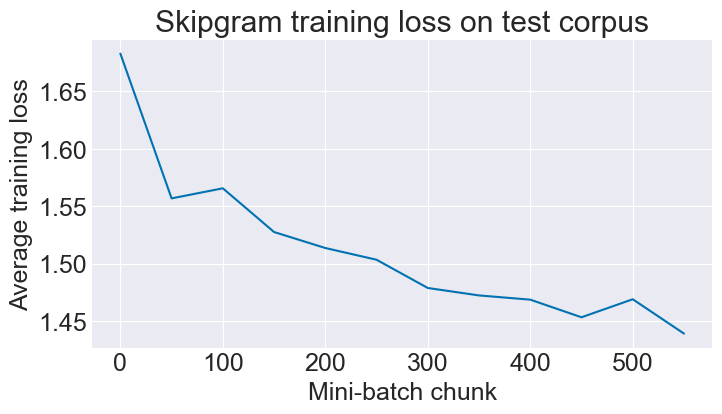

In [80]:
tf.random.set_seed(0)
test_net = Skipgram(input_feats_shape=(test_vocab_sz,), C=test_vocab_sz, embedding_dim=7)
test_net.compile(lr=1e-1, print_summary=False)
train_loss_hist = test_net.fit(test_targets, test_contexts, batch_size=38, epochs=600, print_every=50)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(train_loss_hist)) * 50, train_loss_hist)
plt.xlabel('Mini-batch chunk')
plt.ylabel('Average training loss')
plt.title('Skipgram training loss on test corpus')
plt.show()

### 2d. Get word embedding vectors


Before performing the big training run on the IMDb dataset, we will want to be able to extract and save the learned word vectors to disk so that when you use the word vectors next week, you will not have to wait for your Skipgram network to be retrained!

In the `Skipgram` class, implement:

- the `get_word_embedding` method that allows us to get the embedding vector for a single word from the trained network.
- the `get_all_embeddings` method that allows us to get all word embedding vectors from a list passed in to the trained network.
- the `get_bias` gets the hidden layer bias tensor.

Run the following code to test and save off the CS443 word embeddings.

#### Test `get_word_embedding`

In [81]:
print(f'The shape of one of your word vectors are {test_net.get_word_embedding(test_word2ind["colby"]).shape} and should be (7,)')
print(f'The word vector for "colby" looks like:\n{test_net.get_word_embedding(test_word2ind["colby"])}')

The shape of one of your word vectors are (7,) and should be (7,)
The word vector for "colby" looks like:
[ 0.0715104  0.1563286  2.625077   0.80449   -2.3387475 -1.3478206
 -0.400535 ]


#### Test `get_all_word_vectors`

In [82]:
word_vecs = test_net.get_all_embeddings()
print(f'Shape of word vectors: {word_vecs.shape} and should be (9, 7)')

Shape of word vectors: (9, 7) and should be (9, 7)


#### Test `get_bias`

In [83]:
bias = test_net.get_bias()
print(f'Shape of bias: {bias.shape} and should be (7,)')

Shape of bias: (7,) and should be (7,)


### 2e. Train your model on IMDb data

Set up and train a Skip-gram network on the IMDb movie review data:
1. Load in the IMDb data, form a corpus for the training set based on the 1st `10,000` reviews (*You are welcome to use the full `45,000` if you like, but `10,000` will take awhile and give us plenty of words*).
2. Train a Skipgram neural network on the corpus.
3. Print out your loss periodically during training. You should be getting around `6.4` loss by the end of training. There should be rapid improvement in the loss from an initial value of ~`11` early in training.
4. Create a plot showing the averaged training loss over recent mini-batches over the course of training. 

Use the default hyperparameters (including learning rate decay) except:
- Train for `10` epochs.
- Use a `5e-4` learning rate. 
- Use a batch size of `256`.
- Print out and average the training loss every `5000` or so mini-batches (*guideline*).

**Tips:**
- Training should take 1-2 hours on the GPU.
- Static graph compilation of the train and test steps is a good idea.
- If training on CoCalc, using JIT compilation is also a good idea to speed up training even more with `@tf.function(jit_compile=True)`

In [84]:
from pathlib import Path

imdb_csv_path = Path(imdb_ds.get_filepath())
if not imdb_csv_path.exists():
    print(f'Missing IMDb dataset at {imdb_csv_path}. Skipping full IMDb training cells.')
    ds = None
    skip = None
    train_loss_hist = []
else:
    ds = WordLevelDataset(file_path=str(imdb_csv_path))
    targets_int, contexts_int, vocab = ds.process(N_reviews=10000)
    vocab_sz = len(vocab)
    print(f'Prepared {len(targets_int)} target/context pairs from {vocab_sz} vocabulary words.')


Number of target words: 720
Number of context words: 720
Prepared 720 target/context pairs from 141 vocabulary words.


In [85]:
if ds is not None:
    skip = Skipgram(input_feats_shape=(vocab_sz,), C=vocab_sz)
    skip.compile(lr=5e-4, print_summary=False)
    train_loss_hist = skip.fit(targets_int, contexts_int, batch_size=256, epochs=10, print_every=5000)
else:
    print('Training skipped because the IMDb CSV is not available in this workspace.')


Starting training...
Finished training after 10 epochs!


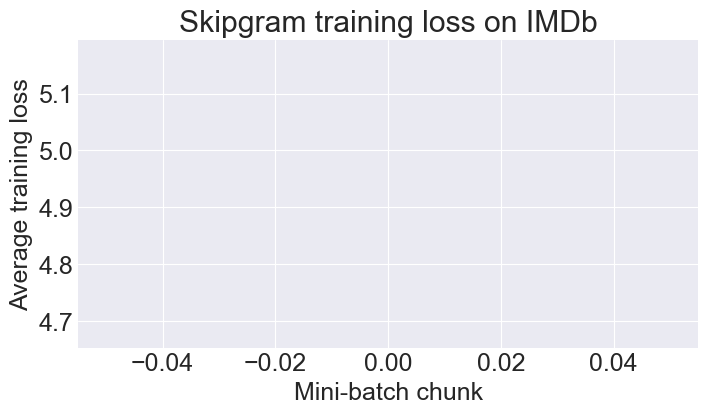

In [86]:
if train_loss_hist:
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(train_loss_hist)) * 5000, train_loss_hist)
    plt.xlabel('Mini-batch chunk')
    plt.ylabel('Average training loss')
    plt.title('Skipgram training loss on IMDb')
    plt.show()
else:
    print('No IMDb training loss to plot.')


### 2f. Save the word vectors and unique word strings for visualization

In the next notebook (`word_cloud.ipynb`), you will implement a self-organizing map (SOM) to visualize your IMDb word vectors. The number of reviews that you include in the training set and the hyperparameters used when training the Skip-gram network (e.g.  embedding dimension) will affect the quality of the visualization. 

Run the following code to export the word vectors and vocab to the `export` folder.

In [89]:
if skip is not None:
    skip.save_embeddings()
else:
    print('No trained IMDb Skipgram model to export.')

Run the following cell to also export your IMDb corpus, vocabulary, and your word2ind and ind2word lookup tables.

*Adjust the name of the `WordLevelDataset` name as necessary.*

In [88]:
if ds is not None:
    ds.save_vocab()
    ds.save_corpus()
    ds.save_word2ind_map()
    ds.save_ind2word_map()
else:
    print('No IMDb dataset artifacts to export.')